# Text Representation: Bag Of Words 

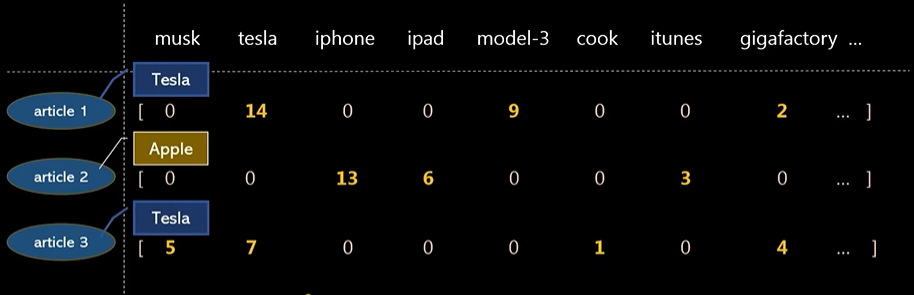

### Disadvantages

1. Consumes more memory 
2. Doesn't capture the meaning of words properly.

In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('spam.csv')
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.Category.value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

In [17]:
df.shape

(5572, 3)

Created new column named 'spam' to represent:
    
    spam -> 1
    ham -> 0 

In [10]:
def get_spam_number(x):
    if x == 'spam':
        return 1
    else:
        return 0

In [12]:
df['spam'] = df['Category'].apply(get_spam_number)

df.head()

,Category,Message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df['Message'], df['spam'], test_size=0.2)

In [15]:
X_train.shape

(4457,)

In [16]:
X_test.shape

(1115,)

In [18]:
type(X_train)

pandas.core.series.Series

In [19]:
X_train[:4]

5025                               Where you. What happen
2215    Ok then i'll let him noe later n ask him call ...
4611                      Just glad to be talking to you.
2892    Yeah there's quite a bit left, I'll swing by t...
Name: Message, dtype: object

In [20]:
type(y_train)

pandas.core.series.Series

In [21]:
y_train[:4]

5025    0
2215    0
4611    0
2892    0
Name: spam, dtype: int64

In [30]:
from sklearn.feature_extraction.text import CountVectorizer

v = CountVectorizer()

X_train_cv = v.fit_transform(X_train.values)
X_train_cv

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 59163 stored elements and shape (4457, 7732)>

In [31]:
X_train_cv.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(4457, 7732))

In [32]:
X_train_cv.shape

(4457, 7732)

In [34]:
v.get_feature_names_out()[1000:1050]

array(['anybody', 'anyhow', 'anymore', 'anyone', 'anyplaces', 'anythin',
       'anything', 'anythingtomorrow', 'anytime', 'anyway', 'anyways',
       'anywhere', 'aom', 'apart', 'apartment', 'apes', 'aphex',
       'apologetic', 'apologise', 'apologize', 'apology', 'app',
       'apparently', 'appeal', 'appear', 'applausestore', 'applebees',
       'apples', 'application', 'apply', 'applyed', 'applying',
       'appointment', 'appreciate', 'appreciated', 'approaching',
       'appropriate', 'approve', 'approx', 'apps', 'appt', 'appy',
       'april', 'aproach', 'apt', 'aptitude', 'aquarius', 'ar', 'arabian',
       'arcade'], dtype=object)

In [35]:
v.get_feature_names_out().shape

(7732,)

In [37]:
dir(v)

['_CountVectorizer__metadata_request__fit',
 '_CountVectorizer__metadata_request__transform',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_build_request_for_signature',
 '_char_ngrams',
 '_char_wb_ngrams',
 '_check_stop_words_consistency',
 '_check_vocabulary',
 '_count_vocab',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_params_html',
 '_html_repr',
 '_limit_features',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr

In [38]:
v.vocabulary_

{'where': 7460,
 'you': 7691,
 'what': 7450,
 'happen': 3319,
 'ok': 4906,
 'then': 6813,
 'll': 4157,
 'let': 4082,
 'him': 3428,
 'noe': 4787,
 'later': 4024,
 'ask': 1092,
 'call': 1609,
 'tmr': 6911,
 'just': 3866,
 'glad': 3138,
 'to': 6916,
 'be': 1269,
 'talking': 6693,
 'yeah': 7663,
 'there': 6816,
 'quite': 5521,
 'bit': 1367,
 'left': 4064,
 'swing': 6655,
 'by': 1593,
 'tomorrow': 6943,
 'when': 7457,
 'get': 3107,
 'up': 7168,
 'no': 4783,
 'da': 2140,
 'vijay': 7271,
 'going': 3163,
 'talk': 6691,
 'in': 3642,
 'jaya': 3792,
 'tv': 7073,
 'ur': 7183,
 'awarded': 1167,
 'city': 1814,
 'break': 1489,
 'and': 969,
 'could': 2030,
 'win': 7497,
 '200': 338,
 'summer': 6588,
 'shopping': 6100,
 'spree': 6398,
 'every': 2661,
 'wk': 7536,
 'txt': 7083,
 'store': 6492,
 '88039': 698,
 'skilgme': 6191,
 'tscs087147403231winawk': 7053,
 'age16': 867,
 '50perwksub': 540,
 'sure': 6617,
 'am': 939,
 'my': 4656,
 'relatives': 5661,
 'home': 3470,
 'sms': 6254,
 'me': 4397,
 'de': 218

In [51]:
X_train_np = X_train_cv.toarray()
X_train_np[:4][0]

array([0, 0, 0, ..., 0, 0, 0], shape=(7732,))

In [52]:
np.where(X_train_np[0] != 0)

(array([3319, 7450, 7460, 7691]),)

In [54]:
X_train_np[0][1771]

np.int64(0)

In [55]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_cv, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [56]:
X_test_cv = v.transform(X_test)

In [58]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test_cv)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       971
           1       0.94      0.92      0.93       144

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [61]:
emails = [
    'Hey mohan, can we get together to watch football game tomorrow?',
    'Upto 20% discount on parking, exclusive offer just for you. Dont miss this reward!'
]

email_count = v.transform(emails)
model.predict(email_count)

array([0, 1])

In [62]:
from sklearn.pipeline import Pipeline

clf = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('nb', MultinomialNB())
])

In [63]:
clf.fit(X_train, y_train)

,steps,"[('vectorizer', ...), ('nb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [69]:
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       971
           1       0.94      0.92      0.93       144

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115

